In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

In [3]:
X = np.array([
    [1, 2], [2, 2], [2, 3], [3, 3], [3, 4],
    [8, 8], [9, 8], [8, 9],
    [20, 20]   # Outlier
])

k = 2  # number of neighbors

In [5]:
dist_matrix = cdist(X, X)

# Step 2: Get k-nearest neighbors
neighbors = []
for i in range(len(X)):
    sorted_idx = np.argsort(dist_matrix[i])
    neighbors.append(sorted_idx[1:k+1])  # exclude itself

neighbors = np.array(neighbors)

In [7]:
def chaining_distance(i):
    neigh = list(neighbors[i])
    visited = [i]
    total_dist = 0

    current = i
    for _ in range(len(neigh)):
        # Find nearest unvisited neighbor
        candidates = [n for n in neigh if n not in visited]
        if not candidates:
            break

        dists = [dist_matrix[current][c] for c in candidates]
        next_point = candidates[np.argmin(dists)]

        total_dist += dist_matrix[current][next_point]
        visited.append(next_point)
        current = next_point

    return total_dist / k

In [9]:
cof_scores = []

for i in range(len(X)):
    acd_i = chaining_distance(i)

    neighbor_acd = np.mean([chaining_distance(n) for n in neighbors[i]])

    if neighbor_acd == 0:
        cof_scores.append(0)
    else:
        cof_scores.append(acd_i / neighbor_acd)

cof_scores = np.array(cof_scores)

In [11]:
threshold = np.percentile(cof_scores, 90)
outliers = cof_scores > threshold

COF Scores: [0.82842712 1.09383632 1.         1.09383632 0.82842712 1.20710678
 0.90616368 0.90616368 8.84651708]
Outliers:
 [[20 20]]


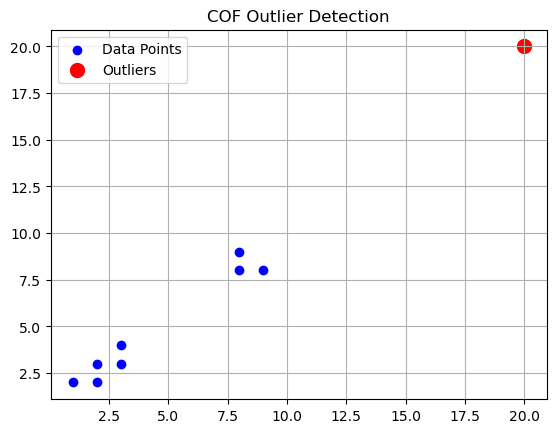

In [13]:
print("COF Scores:", cof_scores)
print("Outliers:\n", X[outliers])

# Step 6: Visualization
plt.scatter(X[:, 0], X[:, 1], color='blue', label='Data Points')

if np.any(outliers):
    plt.scatter(X[outliers][:, 0], X[outliers][:, 1],
                color='red', s=100, label='Outliers')

plt.title("COF Outlier Detection")
plt.legend()
plt.grid()
plt.show()